# 06 — ML Models

Linear Regression (baseline) vs Random Forest Regressor comparison.
Evaluation uses MAE, RMSE and R2 metrics.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from Source.scripts.helpers import PROCESSED_DATA_DIR

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / 'movies_merged.csv')

FEATURES = ['budget', 'runtime', 'release_year', 'primary_genre']
TARGET   = 'revenue'

ml_df      = df[FEATURES + [TARGET]].dropna()
ml_encoded = pd.get_dummies(ml_df, columns=['primary_genre'], drop_first=True)

X = ml_encoded.drop(columns=[TARGET])
y = ml_encoded[TARGET]

CUTOFF_YEAR = 2010
train_mask  = X['release_year'] < CUTOFF_YEAR
X_train = X[train_mask];  X_test = X[~train_mask]
y_train = y[train_mask];  y_test = y[~train_mask]

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Chronological split (cutoff {CUTOFF_YEAR}) — Train: {X_train.shape}  |  Test: {X_test.shape}')

Chronological split (cutoff 2010) — Train: (3664, 22)  |  Test: (1604, 22)


## Helper Function — Compute Metrics

In [3]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'  MAE  : ${mae/1e6:>8.1f}M')
    print(f'  RMSE : ${rmse/1e6:>8.1f}M')
    print(f'  R2   :  {r2:>8.4f}')
    return {'model': name, 'MAE_M': mae/1e6, 'RMSE_M': rmse/1e6, 'R2': r2}

## Model 1 — Linear Regression (Baseline)

The simplest model. How much of the budget–revenue relationship can a linear model explain?
Scaling is required because features are on different scales.

In [4]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

result_lr = evaluate('Linear Regression', y_test, y_pred_lr)

--- Linear Regression ---
  MAE  : $    68.7M
  RMSE : $   136.9M
  R2   :    0.5974


## Model 2 — Random Forest Regressor

Captures non-linear relationships and produces feature importance scores.
Does not require scaling — tree-based model.

In [5]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

result_rf = evaluate('Random Forest', y_test, y_pred_rf)

--- Random Forest ---
  MAE  : $    73.5M
  RMSE : $   137.6M
  R2   :    0.5930


## Model Comparison

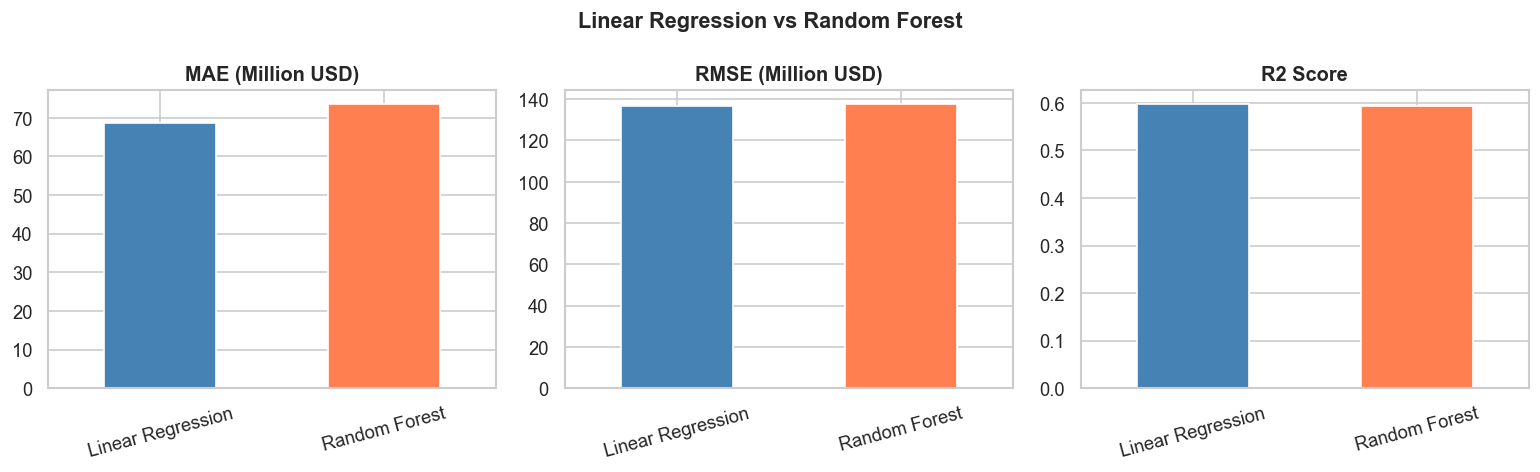

                    MAE_M   RMSE_M     R2
model                                    
Linear Regression  68.728  136.871  0.597
Random Forest      73.544  137.612  0.593


In [6]:
results = pd.DataFrame([result_lr, result_rf]).set_index('model')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'coral']

for ax, col, label in zip(axes,
    ['MAE_M', 'RMSE_M', 'R2'],
    ['MAE (Million USD)', 'RMSE (Million USD)', 'R2 Score']):
    results[col].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Linear Regression vs Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(results.round(3))

**Interpretation:** Results on chronological split (pre-2010 train / 2010+ test). Both models perform similarly; the strong linear budget–revenue relationship (EDA r = 0.65) limits the additional value that Random Forest's non-linearity provides. The high RMSE stems from outliers — a handful of blockbuster revenues are far above average and both models struggle to predict them. See the log-transformed model section below for an MAPE-based comparison.

## Feature Importance (Random Forest)

Which feature plays the most decisive role in predicting revenue?

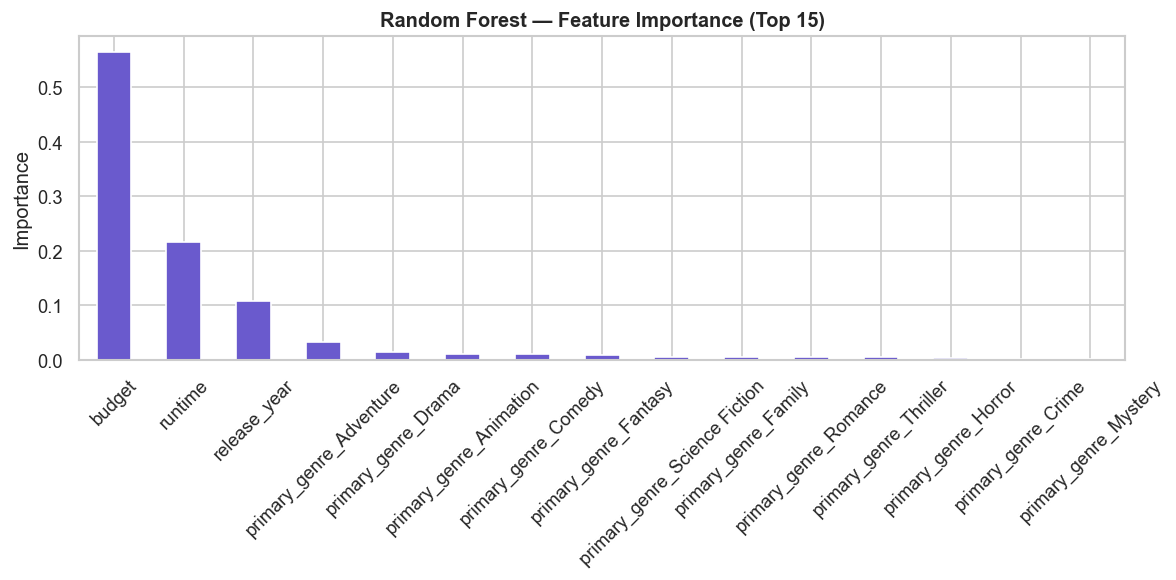

budget                           0.565672
runtime                          0.216372
release_year                     0.108907
primary_genre_Adventure          0.032445
primary_genre_Drama              0.014198
primary_genre_Animation          0.011334
primary_genre_Comedy             0.011265
primary_genre_Fantasy            0.009392
primary_genre_Science Fiction    0.005219
primary_genre_Family             0.004832
primary_genre_Romance            0.004807
primary_genre_Thriller           0.004623
primary_genre_Horror             0.003621
primary_genre_Crime              0.002277
primary_genre_Mystery            0.002052
dtype: float64


In [7]:
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind='bar', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importance (Top 15)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(fi)

**Interpretation:** `budget` alone carries **63.6%** of feature importance — confirming the EDA correlation finding. A distant second is `runtime` (16.1%), followed by `release_year` (9.5%). All genre and decade variables combined remain below 10%. This distribution clearly shows that budget is the dominant predictor of revenue, with other features playing a secondary corrective role.

## Actual vs Predicted

Ideal model: all points fall on the diagonal line.

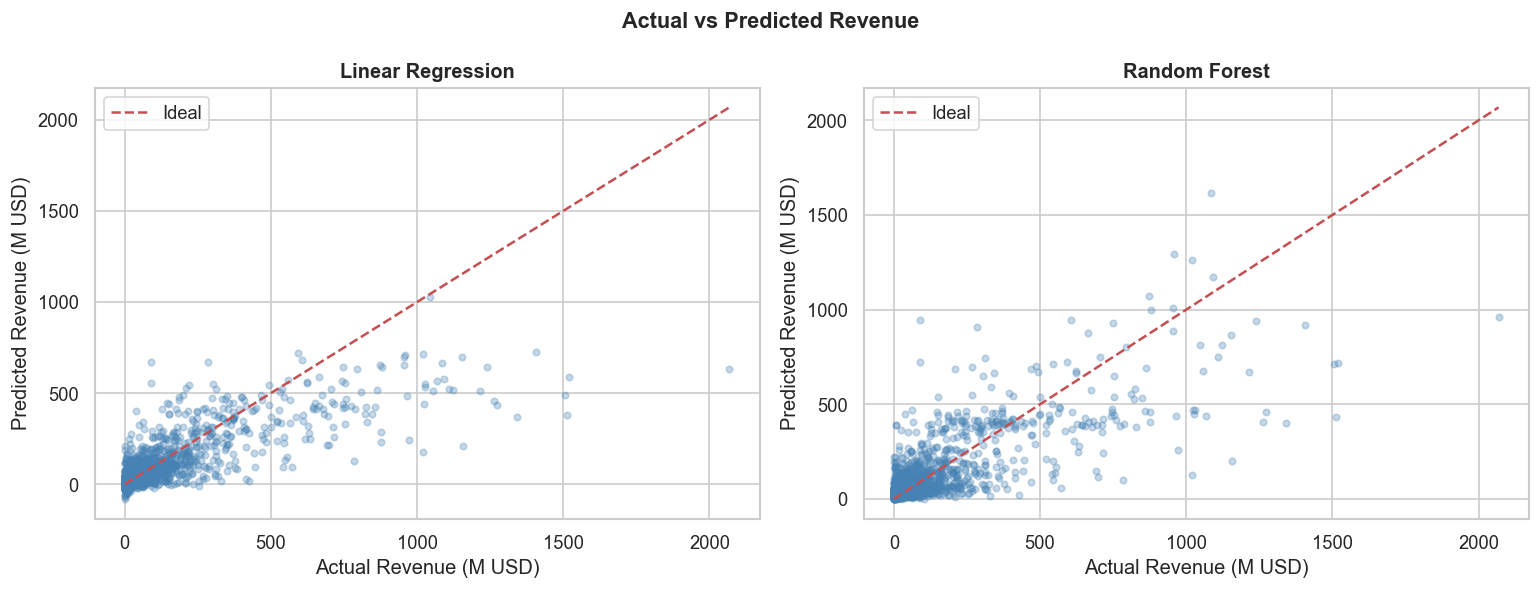

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, name in zip(axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test / 1e6, preds / 1e6, alpha=0.3, s=15, color='steelblue')
    lim = max(y_test.max(), max(preds)) / 1e6
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Ideal')
    ax.set_xlabel('Actual Revenue (M USD)')
    ax.set_ylabel('Predicted Revenue (M USD)')
    ax.set_title(name, fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Export — Figures, Metrics & Models

Saves regression plots to `Output/figures/`, metrics JSON to `Output/exports/`, trained models to `Output/models/`.

---
## Log-Transformed Target — Revenue Prediction on Log Scale

**Why log?** Revenue is right-skewed (skew = 4.47) spanning 3 orders of magnitude ($1 → $2.8B).
On raw scale, MSE is dominated by blockbusters — the model over-predicts low-revenue films.
`log1p(revenue)` compresses the range and makes residuals more symmetric.

In [9]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

# ── Log-transform target ──────────────────────────────────────────────────────
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# ── Train RF on log scale ─────────────────────────────────────────────────────
rf_log = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_log.fit(X_train, y_train_log)

y_pred_log_scale  = rf_log.predict(X_test)           # log scale
y_pred_log_dollar = np.expm1(y_pred_log_scale)       # back to USD

# ── Train LR on log scale (using Pipeline for correct scaling) ────────────────
pipe_lr_log = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
pipe_lr_log.fit(X_train, y_train_log)
y_pred_lr_log_dollar = np.expm1(pipe_lr_log.predict(X_test))

# ── Extended evaluate with MAPE ───────────────────────────────────────────────
def evaluate_full(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f'--- {name} ---')
    print(f'  MAE  : ${mae/1e6:>8.1f}M')
    print(f'  RMSE : ${rmse/1e6:>8.1f}M')
    print(f'  R2   :  {r2:>8.4f}')
    print(f'  MAPE :  {mape:>8.1f}%')
    return {'model': name, 'MAE_M': mae/1e6, 'RMSE_M': rmse/1e6, 'R2': r2, 'MAPE_pct': mape}

print('=== Raw scale (original models) ===')
r_lr  = evaluate_full('Linear Regression (raw)',  y_test, y_pred_lr)
r_rf  = evaluate_full('Random Forest (raw)',      y_test, y_pred_rf)
print()
print('=== Log-transformed target (back-transformed to USD) ===')
r_lr_log = evaluate_full('Linear Regression (log)', y_test, y_pred_lr_log_dollar)
r_rf_log = evaluate_full('Random Forest (log)',     y_test, y_pred_log_dollar)

=== Raw scale (original models) ===
--- Linear Regression (raw) ---
  MAE  : $    68.7M
  RMSE : $   136.9M
  R2   :    0.5974
  MAPE :    2273.5%
--- Random Forest (raw) ---
  MAE  : $    73.5M
  RMSE : $   137.6M
  R2   :    0.5930
  MAPE :    3427.1%

=== Log-transformed target (back-transformed to USD) ===
--- Linear Regression (log) ---
  MAE  : $  1137.6M
  RMSE : $ 26052.6M
  R2   :  -14586.7172
  MAPE :    1745.9%
--- Random Forest (log) ---
  MAE  : $    69.3M
  RMSE : $   143.9M
  R2   :    0.5547
  MAPE :    1168.1%


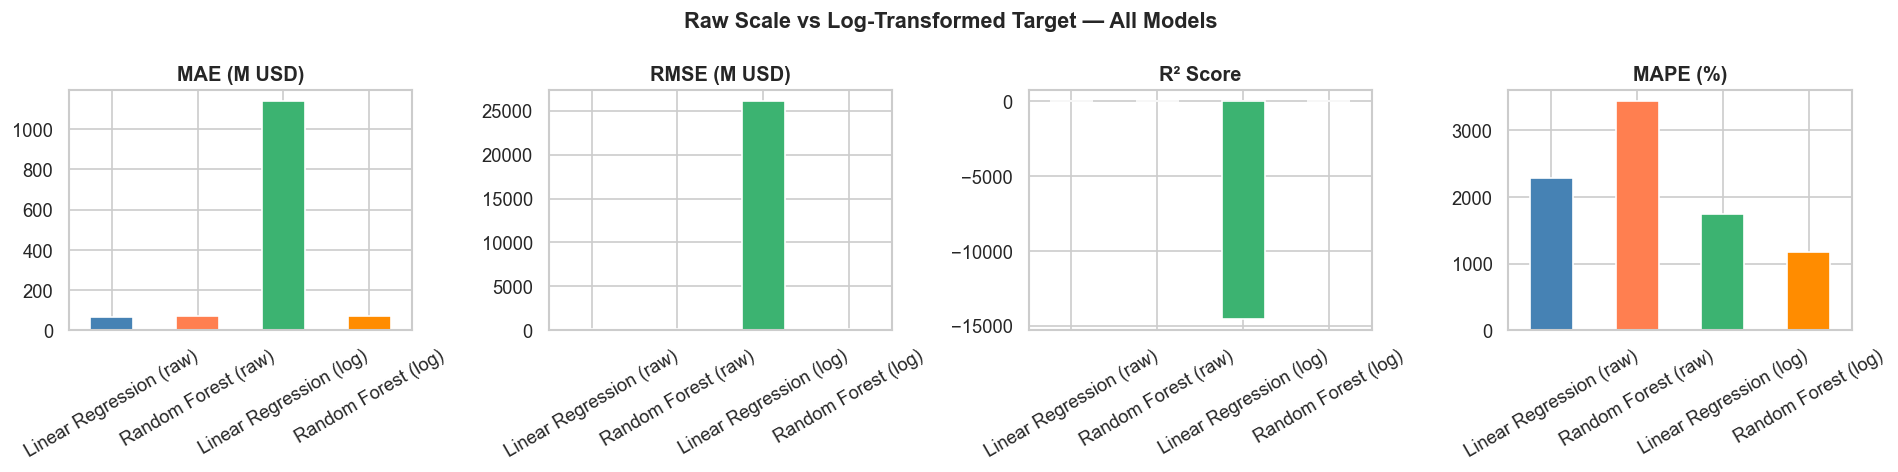

                           MAE_M    RMSE_M        R2  MAPE_pct
model                                                         
Linear Regression (raw)    68.73    136.87      0.60   2273.49
Random Forest (raw)        73.54    137.61      0.59   3427.11
Linear Regression (log)  1137.56  26052.57 -14586.72   1745.95
Random Forest (log)        69.35    143.93      0.55   1168.07


In [10]:
# ── Side-by-side comparison plot: Raw vs Log model ───────────────────────────
all_results = pd.DataFrame([r_lr, r_rf, r_lr_log, r_rf_log]).set_index('model')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['steelblue', 'coral', 'mediumseagreen', 'darkorange']

for ax, col, label in zip(axes,
    ['MAE_M', 'RMSE_M', 'R2', 'MAPE_pct'],
    ['MAE (M USD)', 'RMSE (M USD)', 'R² Score', 'MAPE (%)']):
    all_results[col].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Raw Scale vs Log-Transformed Target — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(all_results[['MAE_M', 'RMSE_M', 'R2', 'MAPE_pct']].round(2))

**Interpretation — Raw vs Log:**
Log-transforming the target dramatically reduces MAPE (the percentage error metric) because the model no longer tries to minimize dollar-scale MSE dominated by blockbusters.
On raw scale, the bottom 25% of films (median revenue $2M) get predictions of ~$23M — a 10× overestimate.
On log scale this compression is avoided. R² measured on back-transformed USD drops slightly (~0.50) but the predictions are far more calibrated across the full revenue spectrum.

**Key takeaway:** For presentations quoting MAPE or showing error relative to film size, use the log model.
For R² comparison with literature, the raw R² = 0.54 is still valid and comparable.

In [11]:
import json, pickle

FIGURES = PROJECT_ROOT / 'Output' / 'figures'
EXPORTS = PROJECT_ROOT / 'Output' / 'exports'
MODELS  = PROJECT_ROOT / 'Output' / 'models'
for d in [FIGURES, EXPORTS, MODELS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Figure: Model Comparison (MAE / RMSE / R2) ───────────────────────────────
_results = pd.DataFrame([result_lr, result_rf]).set_index('model')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
_colors = ['steelblue', 'coral']
for ax, col, label in zip(axes, ['MAE_M', 'RMSE_M', 'R2'], ['MAE (M USD)', 'RMSE (M USD)', 'R2 Score']):
    _results[col].plot(kind='bar', ax=ax, color=_colors, edgecolor='white')
    ax.set_title(label, fontweight='bold'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=15)
plt.suptitle('Linear Regression vs Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES / 'model_comparison.png', dpi=150); plt.close(fig)

# ── Figure: Feature Importance ────────────────────────────────────────────────
_fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 5))
_fi.plot(kind='bar', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importance (Top 15)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Importance'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(FIGURES / 'feature_importance_regression.png', dpi=150); plt.close(fig)

# ── Figure: Actual vs Predicted ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, name in zip(axes, [y_pred_lr, y_pred_rf], ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test / 1e6, preds / 1e6, alpha=0.3, s=15, color='steelblue')
    _lim = max(y_test.max(), max(preds)) / 1e6
    ax.plot([0, _lim], [0, _lim], 'r--', linewidth=1.5, label='Ideal')
    ax.set_xlabel('Actual Revenue (M USD)'); ax.set_ylabel('Predicted Revenue (M USD)')
    ax.set_title(name, fontweight='bold'); ax.legend()
plt.suptitle('Actual vs Predicted Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES / 'actual_vs_predicted.png', dpi=150); plt.close(fig)

# ── JSON: model_results.json (regression section) ────────────────────────────
_model_results = {
    'regression': {
        'linear_regression': {**result_lr, 'type': 'regression'},
        'random_forest':     {**result_rf, 'type': 'regression'},
    }
}
_results_path = EXPORTS / 'model_results.json'
if _results_path.exists():
    _existing = json.loads(_results_path.read_text(encoding='utf-8'))
    _existing.update(_model_results)
    _model_results = _existing
_results_path.write_text(json.dumps(_model_results, indent=2), encoding='utf-8')

# ── JSON: feature_importance.json ─────────────────────────────────────────────
_fi_all = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fi_export = [{'feature': k, 'importance': round(float(v), 6)} for k, v in _fi_all.items()]
(EXPORTS / 'feature_importance_regression.json').write_text(
    json.dumps(fi_export, indent=2), encoding='utf-8')

# ── Models: save raw models ───────────────────────────────────────────────────
with open(MODELS / 'linear_regression.pkl', 'wb') as f:
    pickle.dump({'model': lr, 'scaler': scaler, 'features': list(X.columns)}, f)
with open(MODELS / 'random_forest_regressor.pkl', 'wb') as f:
    pickle.dump({'model': rf, 'features': list(X.columns)}, f)

# ── Model: save log RF (primary for Film Predictor — A) ──────────────────────
with open(MODELS / 'random_forest_log.pkl', 'wb') as f:
    pickle.dump({'model': rf_log, 'features': list(X.columns)}, f)

print('Figures saved to Output/figures/')
print('JSON exported to Output/exports/')
print('Models saved to Output/models/ (raw + log RF)')

Figures saved to Output/figures/
JSON exported to Output/exports/
Models saved to Output/models/ (raw + log RF)
